### **Import library**

In [28]:
from sklearn import datasets
from sklearn.preprocessing import LabelEncoder


### **Load dataset**

In [29]:
import pandas as pd
df = pd.read_csv("Student_Performance_2026.csv")

# diabetes = datasets.load_diabetes()

In [6]:
df

,student_ID,Age,Gender,daily_screen_time_hours,social_media_hours,online_study_hours,gaming_hours,sleep_hours,attendance_percentage,offline_study_hours,previous_sem_CGPA,current_sem_CGPA
0,S011,23,Female,6.2,2.5,3.8,1.2,7.1,79,2.6,7.74,7.94
1,S012,24,Female,4.9,2.0,5.1,1.0,8.3,79,2.6,7.72,7.92
2,S013,18,Female,7.9,3.2,2.1,1.6,7.1,68,2.3,6.67,6.87
3,S014,17,Male,10.0,4.0,0.0,2.0,5.9,63,2.1,6.10,6.30
4,S015,23,Female,7.7,3.1,2.3,1.5,6.4,69,2.3,6.77,6.97
...,...,...,...,...,...,...,...,...,...,...,...,...
541,S552,17,Male,4.1,1.6,5.9,0.8,8.2,78,2.6,7.63,7.83
542,S553,24,Female,6.4,2.6,3.6,1.3,7.5,79,2.6,7.74,7.94
543,S554,17,Male,8.3,3.3,1.7,1.7,6.0,58,1.9,5.62,5.82
544,S555,21,Female,9.8,3.9,0.2,2.0,6.3,64,2.2,6.29,6.49


### **Create X and Y data matrices**

In [57]:
X = df.drop("current_sem_CGPA", axis=1)
X = X.drop("student_ID", axis=1)
X["Gender"] = LabelEncoder().fit_transform(X["Gender"])
X = X.drop("previous_sem_CGPA", axis=1)  # remove this

Y = df["current_sem_CGPA"]

## **Data split**

### **Import library**

In [58]:
from sklearn.model_selection import train_test_split

### **Perform 80/20 Data split**

In [59]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

### **Data dimension**

In [60]:
X_train.shape, Y_train.shape

((436, 9), (436,))

In [61]:
X_test.shape, Y_test.shape

((110, 9), (110,))

## **Linear Regression Model**

### **Import library**

In [62]:
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score

### **Build linear regression**

#### Defines the regression model

In [63]:
model = linear_model.LinearRegression()
df.select_dtypes(include=['object']).head()


/tmp/ipykernel_537915/211772757.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include=['object']).head()


,student_ID,Gender
0,S011,Female
1,S012,Female
2,S013,Female
3,S014,Male
4,S015,Female


#### Build training model

In [64]:
model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### Apply trained model to make prediction (on test set)

In [65]:
Y_pred = model.predict(X_test)

## **Prediction results**

### **Print model performance**

In [66]:
print('Coefficients:', model.coef_)
print('Intercept:', model.intercept_)
print('Mean squared error (MSE): %.2f'
      % mean_squared_error(Y_test, Y_pred))
print('Coefficient of determination (R^2): %.2f'
      % r2_score(Y_test, Y_pred))

Coefficients: [-5.89229779e-05  1.24544854e-04  1.65368636e-02 -5.36963252e-02
 -1.65368636e-02 -4.90549705e-02  3.44218918e-03  8.63706479e-02
  4.10449426e-01]
Intercept: 0.1663008941879056
Mean squared error (MSE): 0.00
Coefficient of determination (R^2): 1.00


### **String formatting**

By default r2_score returns a floating number ([more details](https://docs.scipy.org/doc/numpy-1.13.0/user/basics.types.html))

In [67]:
r2_score(Y_test, Y_pred)

0.9995021168795069

We will be using the modulo operator to format the numbers by rounding it off.

In [68]:
'%f' % 0.523810833536016

'0.523811'

We will now round it off to 3 digits

In [69]:
'%.3f' % 0.523810833536016

'0.524'

We will now round it off to 2 digits

In [70]:
'%.2f' % 0.523810833536016

'0.52'

## **Scatter plots**

### **Import library**

In [71]:
import seaborn as sns

### **Make scatter plot**

#### The Data

In [72]:
Y_test

169    8.26
388    7.73
285    5.91
24     5.51
460    9.38
       ... 
53     7.03
122    6.93
50     5.97
71     7.05
312    6.79
Name: current_sem_CGPA, Length: 110, dtype: float64

In [73]:
import numpy as np
np.array(Y_test)

array([8.26, 7.73, 5.91, 5.51, 9.38, 8.58, 5.77, 7.21, 5.99, 7.46, 8.92,
       7.29, 5.53, 5.69, 6.39, 9.11, 6.53, 7.48, 7.94, 6.27, 5.87, 7.62,
       6.51, 5.73, 8.99, 8.78, 7.27, 7.36, 6.54, 6.37, 6.84, 6.4 , 5.85,
       7.16, 7.42, 7.68, 8.45, 7.14, 5.61, 6.04, 9.61, 8.97, 5.58, 7.67,
       8.99, 9.34, 5.74, 8.16, 9.71, 8.91, 6.36, 5.78, 7.36, 9.17, 7.79,
       6.69, 7.86, 7.92, 9.38, 5.9 , 8.04, 5.7 , 9.12, 7.6 , 7.76, 7.69,
       9.77, 7.45, 8.01, 7.85, 7.68, 6.83, 8.57, 6.85, 6.2 , 7.95, 7.56,
       8.51, 8.74, 9.42, 6.21, 5.75, 7.51, 6.02, 6.57, 7.94, 7.99, 6.11,
       9.29, 7.36, 8.45, 6.3 , 6.23, 7.78, 6.91, 8.94, 8.67, 7.52, 6.05,
       5.62, 7.88, 8.85, 7.81, 6.29, 7.51, 7.03, 6.93, 5.97, 7.05, 6.79])

In [74]:
Y_pred

array([8.26751753, 7.75119083, 5.95367579, 5.52628166, 9.3407657 ,
       8.56261853, 5.73630986, 7.23892181, 5.95266072, 7.45490574,
       8.95542017, 7.23874755, 5.5281206 , 5.65441466, 6.33813289,
       9.12622488, 6.55088741, 7.44946115, 7.92407416, 6.24901613,
       5.86145856, 7.62215022, 6.55610711, 5.73844288, 8.95296563,
       8.73677866, 7.23723526, 7.36904927, 6.55370063, 6.33999925,
       6.8533339 , 6.42505446, 5.8639379 , 7.15258936, 7.44992784,
       7.66563787, 8.43703213, 7.1521898 , 5.65342491, 6.04117423,
       9.63452185, 8.95579589, 5.56450095, 7.66482166, 8.95525941,
       9.34245937, 5.73905637, 8.13729859, 9.72611741, 8.95869552,
       6.33805377, 5.74152335, 7.36875728, 9.16960597, 7.75322674,
       6.63862101, 7.84056023, 7.92415161, 9.34288271, 5.9497208 ,
       8.05033201, 5.73802529, 9.13125848, 7.62609896, 7.753327  ,
       7.66796733, 9.76666878, 7.45125666, 8.05439493, 7.83333814,
       7.66782564, 6.85389098, 8.56983487, 6.84835085, 6.25862

#### Making the scatter plot

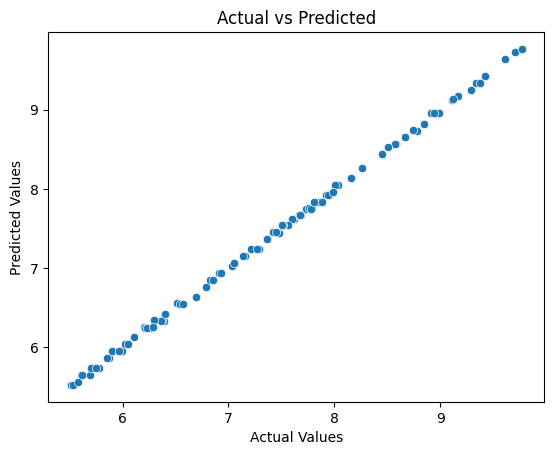

In [75]:
import matplotlib.pyplot as plt

sns.scatterplot(x=Y_test, y=Y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

<Axes: xlabel='current_sem_CGPA'>

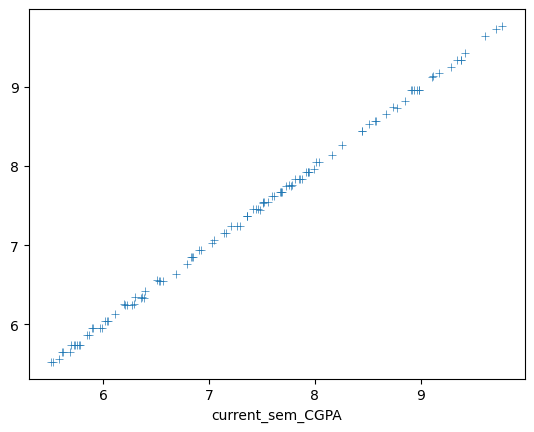

In [76]:
sns.scatterplot(x=Y_test, y=Y_pred, marker="+")

['Age', 'Gender', 'daily_screen_time_hours', 'social_media_hours', 'online_study_hours', 'gaming_hours', 'sleep_hours', 'attendance_percentage', 'offline_study_hours']


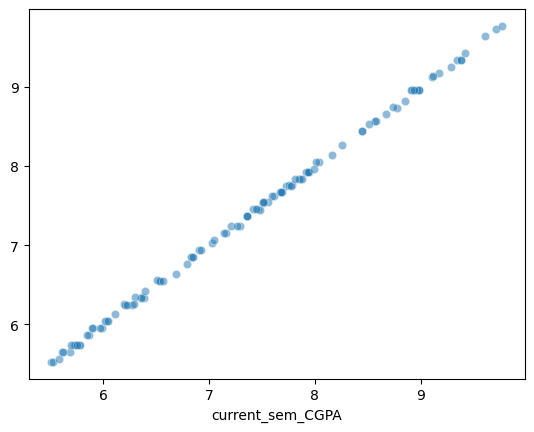

In [77]:
sns.scatterplot(x=Y_test, y=Y_pred, alpha=0.5)
print(X.columns.tolist())